In [2]:
# Target variable: Response  (1 = customer is interested in vehicle insurance, 0 = not interested)
# Project goal: predict which existing health-insurance customers will be interested in
#               vehicle insurance, so the company can focus its cross-sell outreach.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
df = pd.read_csv("/Users/gavalencia/Desktop/insurance_data/train.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
print("Shape: ", df.shape)

Shape:  (381109, 12)


Response
0    334399
1     46710
Name: count, dtype: int64
Response
0    0.8774
1    0.1226
Name: proportion, dtype: float64


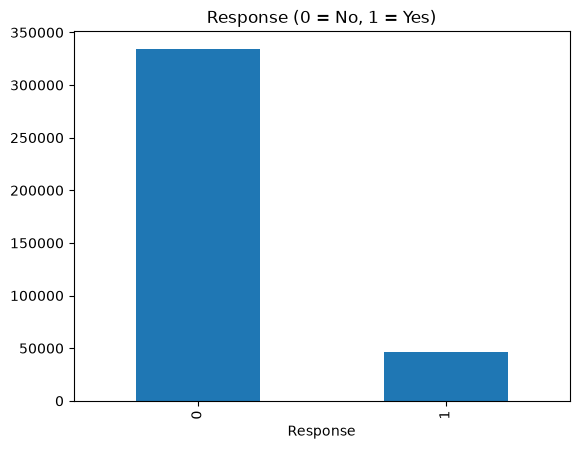

In [6]:
print(df["Response"].value_counts())
print(df["Response"].value_counts(normalize=True).round(4))

df["Response"].value_counts().plot(kind="bar", title="Response (0 = No, 1 = Yes)")
plt.show()


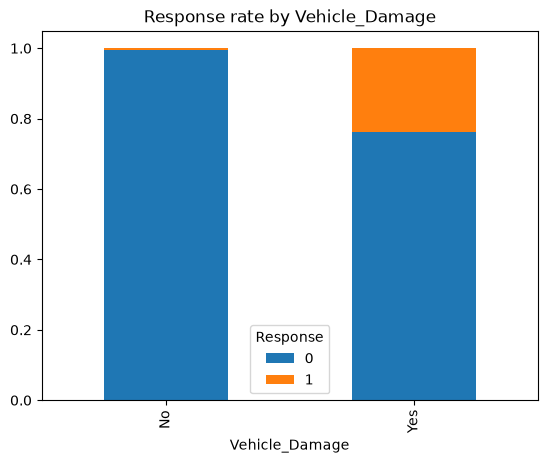

In [7]:
pd.crosstab(df["Vehicle_Damage"], df["Response"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Response rate by Vehicle_Damage")
plt.show()

In [9]:
df.select_dtypes("number").corr()["Response"].sort_values(ascending=False)


Response                1.000000
Age                     0.111147
Annual_Premium          0.022575
Region_Code             0.010570
Driving_License         0.010155
Vintage                -0.001050
id                     -0.001368
Policy_Sales_Channel   -0.139042
Previously_Insured     -0.341170
Name: Response, dtype: float64

In [10]:
df_model = df.drop(columns=["id"])
df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})
df_model["Vehicle_Damage"] = df_model["Vehicle_Damage"].map({"Yes": 1, "No": 0})
df_model["Vehicle_Age"] = df_model["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df_model.head()


,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,1,76,1,3.0,0,1,0,33536.0,26.0,183,0
2,1,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,1,21,1,11.0,1,0,0,28619.0,152.0,203,0
4,0,29,1,41.0,1,0,0,27496.0,152.0,39,0


In [11]:
X = df_model.drop(columns=["Response"])
y = df_model["Response"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)


(304887, 10) (76222, 10)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


ROC-AUC: 0.8336
[[39584 27296]
 [  214  9128]]
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.98      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222



/Users/gavalencia/miniconda3/envs/ads502/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


ROC-AUC: 0.836
[[58964  7916]
 [ 5372  3970]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     66880
           1       0.33      0.42      0.37      9342

    accuracy                           0.83     76222
   macro avg       0.63      0.65      0.64     76222
weighted avg       0.85      0.83      0.83     76222



Vehicle_Damage          0.195702
Vintage                 0.193461
Annual_Premium          0.169835
Previously_Insured      0.140622
Age                     0.119502
Region_Code             0.083188
Policy_Sales_Channel    0.059067
Vehicle_Age             0.028900
Gender                  0.009073
Driving_License         0.000649
dtype: float64


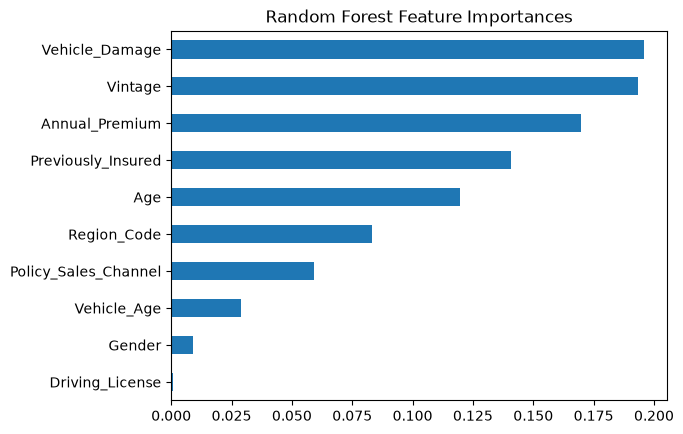

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind="barh", title="Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()


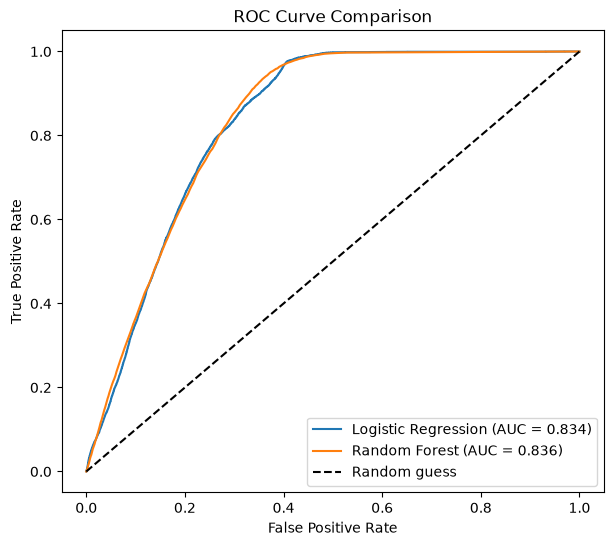

In [16]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


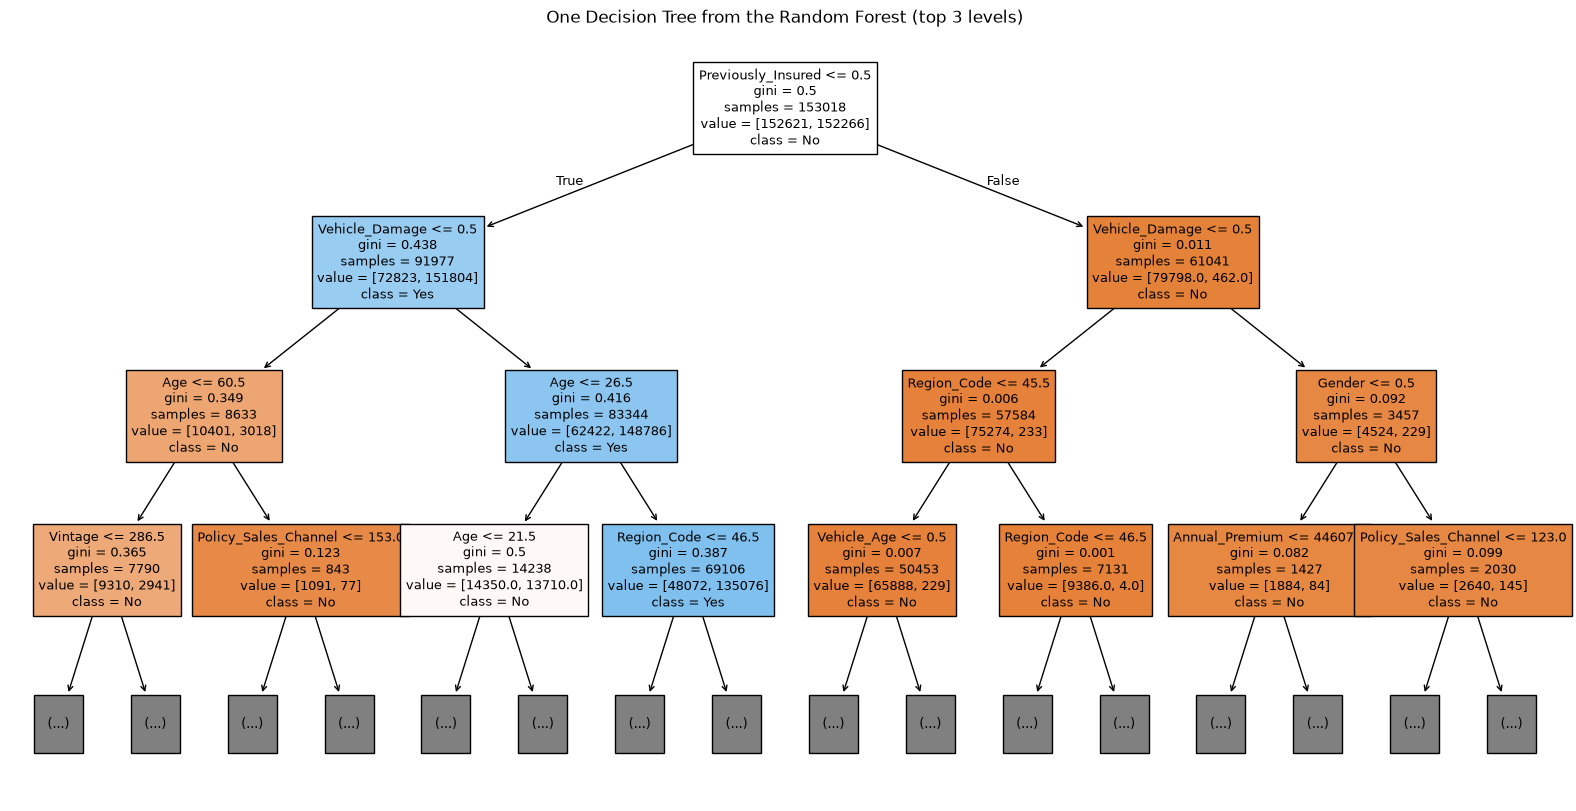

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True, max_depth=3, fontsize=9
)
plt.title("One Decision Tree from the Random Forest (top 3 levels)")
plt.show()


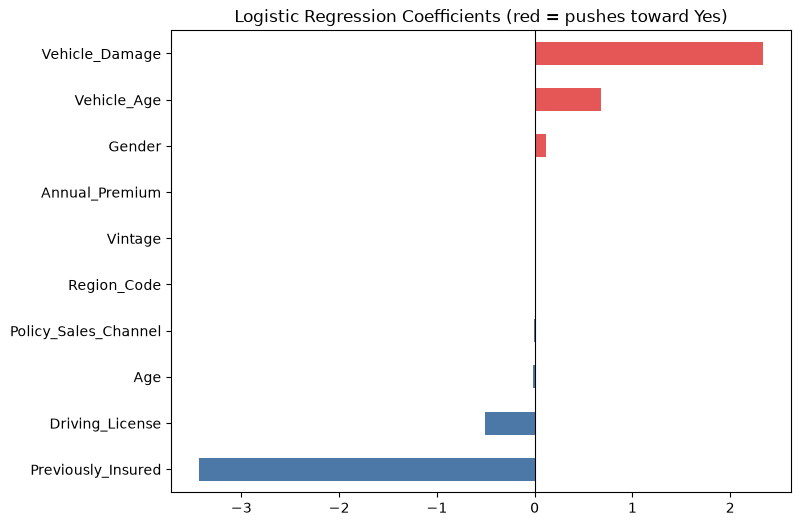

In [19]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

coefs.plot(kind="barh", figsize=(8, 6), color=(coefs > 0).map({True: "#e45756", False: "#4c78a8"}))
plt.title("Logistic Regression Coefficients (red = pushes toward Yes)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()
